<center> <img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fmiro.medium.com%2Fmax%2F450%2F1*CXZ804tKLPy2hiikJbYH3w.png&f=1&nofb=1" width=25% > </center>

<br><br>

<center> 
    <font size="6">Lab 4: Image Alignment, Image Stitching and Panorama Creation</font>
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
</center>

<br><br>

***

<br><br>



### **Import Libraries**

In [1]:
import sys

if sys.version_info[0] < 3:
    raise Exception("Python 3 or a more recent version is required.")

In [2]:
# environment and libraries
import os
import math
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import random

from tqdm.notebook import tqdm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import signal
from matplotlib.patches import ConnectionPatch

In [3]:
# Make sure you're using the provided environment!
assert cv2.__version__ == "4.10.0", "You're not using the provided Python environment!"
assert np.__version__ == "1.26.4", "You're not using the provided Python environment!"
assert matplotlib.__version__ == "3.9.2", "You're not using the provided Python environment!"
# Proceed to the next cell if you don't get any error.

### **Instructions**



It is advised that your notebook follows these guidelines:
- It is mandatory to **use the Python environment provided** with the assignment; the environment specifies the package versions that have to be used to prevent the use of particular functions. Using different packages versions may lead to grade deduction. In the Python cell above you can check whether your environment is set up correctly.
- To install the environment with the right package versions, use the following command in your terminal: ```conda env create --file=CV1_environment.yaml```, then activate the environment using the command ```conda activate cv1```.
- Do not use additional packages or materials that have not been provided or explicitly mentioned.
- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Answer all given questions and sub-questions.
- Try to understand the problem as much as you can. When answering a question, give evidences (qualitative and/or quantitative results, references to papers, figures etc.) to support your arguments. Note that not everything might be explicitly asked for and you are expected to think about what might strengthen you arguments and make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Do not forget to add a number, a title, and if applicable name and unit of variables in a table, name and unit of axes and legends in a figure.



### **Overview**

- [Section 1: Image Alignment ](#section-1)
  - [Question 1 ](#question-1)
  - [Question 2 ](#question-2)
  - [Question 3 ](#question-3)
  - [Question 4 ](#question-4)
  - [Question 5 ](#question-5)
  - [Question 6 ](#question-6)
  - [Question 7 )](#question-7)
  - [Question 8 ](#question-8)
  
- [Section 2: Image Stitching ](#section-2)
  - [Question 9 ](#question-9)
  - [Question 10 ](#question-10)
  - [Question 11 )](#question-11)
  
- [Section 3: Automatic Panorama Stitching ](#section-3)
  - [Question 12 ](#question-12)
  



<a id="section-1"></a>
### **Section 1: Image Alignment**

In this section, you will develop a pipeline that estimates the affine transformation between two images and uses it to align them. You will work with two supplied images of *Genoa Beach*, following a series of steps that involve detecting interest points, describing their local appearance, and matching them between the images. This process is fundamental in many computer vision tasks, such as object recognition, image stitching, and motion tracking.

The procedure is as follows:

1. **Detect, describe and match keypoints (Question 1):**
   - Detect interest points in both images and describe the local appearance around each of them using David Lowe's SIFT (Scale-Invariant Feature Transform).
   - Match the descriptors between the two images to obtain candidate correspondences. For further information, refer to the [SIFT tutorial](https://docs.opencv.org/4.10.0/da/df5/tutorial_py_sift_intro.html) and the [SIFT class documentation](https://docs.opencv.org/4.10.0/d7/d60/classcv_1_1SIFT.html).

2. **Inspect the matches (Question 2):**
   - Visualize a random subset of the matches to get a feel for their quality. You will notice that not all matches are correct.

3. **Estimate the transformation with RANSAC (Question 3):**
   - **Repeat N times:**
     - Randomly select $P$ matched pairs from the full set of matches.
     - Construct the matrix $A$ and vector $b$ from the $P$ pairs and solve $Ax = b$ for the affine parameters $m_1, m_2, m_3, m_4, t_1, t_2$ using least squares, $x = (A^T A)^{-1} A^T b$.
     - Apply the resulting transformation to all matched points of the first image. If the transformation is accurate, the transformed points should lie close to their corresponding points in the second image.
     - Count the inliers: matched pairs whose transformed point lies within a radius of 10 pixels of its corresponding point in the second image.
     - If the number of inliers exceeds the best count so far, keep this transformation.

4. **Transform the first image (Question 4):**
   - Use the best transformation to warp the first image so that it aligns with the second image. Implement both forward and inverse warping using **nearest-neighbor interpolation** (i.e., rounding the transformed coordinates to the nearest pixel).

5. **Compare the warping methods (Question 5):**
   - Compare your forward and inverse warping results with OpenCV's `cv2.warpAffine` and with the reference image.

6. **Analyze the method (Questions 6–8):**
   - Reflect on the minimum number of correspondences needed, what happens when more are used, and how many RANSAC iterations are required.

<a id="question-1"></a>
#### <font color='#FF0000'>Question 1 (5 points)</font>

Create a function named **get_matching_keypoints()** that takes two images as input and returns the matching keypoints between them.

The function should use the SIFT (Scale-Invariant Feature Transform) algorithm to detect and describe keypoints in both images. Once the keypoints are detected, use a brute-force matcher with Euclidean distance to find and return the matches between the two images. Make sure to convert the images to grayscale for processing.

The function should return the keypoints detected in the first image, the keypoints detected in the second image, and the matches found between them. Ensure that the function prints the number of keypoints detected in each image, as well as the number of matches found.

To test your function, use the images `genoa_beach.jpg` and `genoa_beach_cut_1.jpg`.

**Note:** You can use the OpenCV library to implement the SIFT algorithm.

In [4]:
def get_matching_keypoints(image_1, image_2):
    """
    Given two input images, find and return the matching keypoints.

    Args:
        image_1: The first image (in RGB)
        image_2: The second image (in RGB)

    Returns:
        keypoints_image_1: Keypoints detected in the first image
        keypoints_image_2: Keypoints detected in the second image
        matches: Matching keypoints between the two images
    """

    print('Finding matching features...')

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Convert images to grayscale for SIFT processing
    image_1_gray = cv2.cvtColor(image_1, cv2.COLOR_RGB2GRAY)
    image_2_gray = cv2.cvtColor(image_2, cv2.COLOR_RGB2GRAY)

    # Initialize the SIFT detector
    sift = cv2.SIFT_create()

    # Detect keypoints and compute their descriptors using SIFT
    keypoints_image_1, descriptors_image_1 = sift.detectAndCompute(image_1_gray, None)
    keypoints_image_2, descriptors_image_2 = sift.detectAndCompute(image_2_gray, None)

    # Initialize a brute-force matcher with Euclidean distance and cross-check
    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    # Match descriptors between the two images
    matches = matcher.match(descriptors_image_1, descriptors_image_2)

    ## <<< SOLUTION

    # Output the number of keypoints and matches
    print(f"Number of keypoints in the first image:  {len(keypoints_image_1)}")
    print(f"Number of keypoints in the second image: {len(keypoints_image_2)}")
    print(f"Number of matches: {len(matches)}")

    return keypoints_image_1, keypoints_image_2, matches

In [5]:
# YOUR CODE HERE

## >>> SOLUTION

# Load the images
image_1 = cv2.imread('images/genoa_beach.jpg')
# image_1 = cv2.imread('images/sp1.jpg')
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread('images/genoa_beach_cut_1.jpg')
# image_2 = cv2.imread('images/sp2.jpg')
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

# Find matching keypoints
keypoints_image_1, keypoints_image_2, matches = get_matching_keypoints(image_1, image_2)

## <<< SOLUTION

Finding matching features...
Number of keypoints in the first image:  14514
Number of keypoints in the second image: 10245
Number of matches: 6416


<a id="question-2"></a>
#### <font color='#FF0000'>Question 2 (10 points)</font>

Create a function named `draw_random_matches` that takes the matching keypoints found in Question 1, selects a random subset of 10 matching points, and plots them on the images.

The function should connect matching pairs with lines, assigning a random color to each line to make them easier to distinguish. Ensure that the keypoints are marked on both images and that the matching lines are clearly visible. The images should be displayed side by side for easy comparison.

**Hint:** Use `from matplotlib.patches import ConnectionPatch` for drawing the lines between matching keypoints.

In [6]:
## ALT SOLUTION

# student might be tempted to use this cv2 function.
# this solution is not very elegant and is not very clear.
# student will only get some points

def features_deepcopy(f):
    return [cv2.KeyPoint(x = k.pt[0], y = k.pt[1], 
            size = k.size, angle = k.angle, 
            response = k.response, octave = k.octave, 
            class_id = k.class_id) for k in f]

def draw_random_matches(image_1, keypoints_1, image_2, keypoints_2, matches, subset_size=10):
    selected_matches = random.sample(matches, min(subset_size, len(matches)))

    kp1 = features_deepcopy(keypoints_1)
    kp2 = features_deepcopy(keypoints_2)

    for kp in kp1:
        kp.size *= 20
    for kp in kp2:
        kp.size *= 20
    
    img3 = cv2.drawMatches(
        image_1,
        kp1,
        image_2,
        kp2,
        selected_matches,
        None,
        flags=cv2.DrawMatchesFlags_DRAW_RICH_KEYPOINTS + cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )

    plt.figure(figsize=(20,20))
    plt.imshow(img3)
    plt.axis('off')
    plt.show()

In [7]:
def draw_random_matches(image_1, keypoints_1, image_2, keypoints_2, matches, subset_size=10):
    """
    Draw a random subset of matching keypoints between two images.

    Args:
        image_1: The first image (in RGB)
        keypoints_1: Keypoints detected in the first image
        image_2: The second image (in RGB)
        keypoints_2: Keypoints detected in the second image
        matches: Matching keypoints between the two images
        subset_size: Number of random matches to display (default is 10)

    Returns:
        None. The function displays the images with the matching keypoints.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Randomly select a subset of matches
    selected_matches = random.sample(matches, subset_size)

    # Set up the subplot arrangement
    fig, axes = plt.subplots(1, 2, figsize=(15, 15))
    axes[0].imshow(image_1)
    axes[0].axis('off')
    axes[1].imshow(image_2)
    axes[1].axis('off')

    # Extract the indices of the selected keypoints
    idx1 = [m.queryIdx for m in selected_matches]
    idx2 = [m.trainIdx for m in selected_matches]

    # Extract the x and y coordinates of the selected keypoints
    x_1 = [keypoints_1[i].pt[0] for i in idx1]
    y_1 = [keypoints_1[i].pt[1] for i in idx1]
    x_2 = [keypoints_2[i].pt[0] for i in idx2]
    y_2 = [keypoints_2[i].pt[1] for i in idx2]

    # Plot the keypoints on the images
    axes[0].scatter(x_1, y_1, marker='x', color='r')
    axes[1].scatter(x_2, y_2, marker='x', color='r')

    # Add titles to the images
    axes[0].set_title('Image 1')
    axes[1].set_title('Image 2')

    # Draw circles and arrows around the selected keypoints only
    for i in range(subset_size):
        kp1 = keypoints_1[idx1[i]]
        kp2 = keypoints_2[idx2[i]]

        # First image: Draw circle and arrow for each keypoint
        x1, y1 = kp1.pt
        radius1 = kp1.size * 20
        angle1 = kp1.angle * (2 * np.pi) / 360
        axes[0].add_artist(plt.Circle((x1, y1), radius1, fill=False))
        axes[0].add_artist(plt.Arrow(x1, y1, radius1 * np.cos(angle1), radius1 * np.sin(angle1), color='red'))

        # Second image: Draw circle and arrow for each keypoint
        x2, y2 = kp2.pt
        radius2 = kp2.size * 20
        angle2 = kp2.angle * (2 * np.pi) / 360
        axes[1].add_artist(plt.Circle((x2, y2), radius2, fill=False))
        axes[1].add_artist(plt.Arrow(x2, y2, radius2 * np.cos(angle2), radius2 * np.sin(angle2), color='red'))

        # Draw a line connecting the matching keypoints
        connection = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color=(random.uniform(0, 1), random.uniform(0, 1), random.uniform(0, 1))
        )
        axes[1].add_artist(connection)

    # plt.savefig('q2_example.png', bbox_inches='tight')  # AUX
    
    plt.show()

    ## <<< SOLUTION

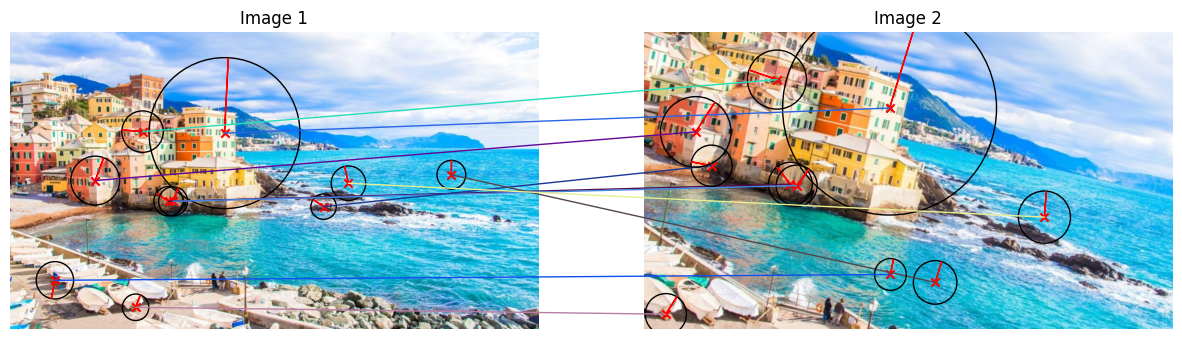

In [8]:
draw_random_matches(image_1, keypoints_image_1, image_2, keypoints_image_2, matches, subset_size=10)

<a id="question-3"></a>
#### <font color='#FF0000'>Question 3 (15 points)</font>

In this question, you will implement the RANSAC algorithm to estimate an affine transformation between two sets of matched keypoints, while ignoring outlier matches. You have to complete the following functions:

1. **compute_affine_transformation_matrix:** Given a set of point correspondences, set up the system $Ax = b$ (see Question 6) and solve it with least squares to obtain the affine transformation matrix.
2. **test_affine_transformation_matrix:** Apply a transformation matrix to all points of the first image and return the indices of the correspondences whose transformed point lies within `threshold` pixels (Euclidean distance) of its matched point in the second image.
3. **ransac_algorithm:** Repeatedly sample `num_points` random correspondences, fit a matrix with (1), count its inliers with (2), and keep the matrix with the most inliers.

Throughout this question, point correspondences are stored as a NumPy array `data` of shape `(N, 4)`, where each row is `[x1, y1, x2, y2]`: a keypoint location `(x1, y1)` in the first image and its match `(x2, y2)` in the second image. Transformation matrices are NumPy arrays of shape `(2, 3)`, in the same layout as the matrix expected by `cv2.warpAffine`:

$
\begin{bmatrix}
m_1 & m_2 & t_1\\
m_3 & m_4 & t_2
\end{bmatrix}
$

**Note:** You are only allowed to use the NumPy library to implement these functions.

In [ ]:
def compute_affine_transformation_matrix(data):
    ## >>> SOLUTION
    data = np.asarray(data, dtype=np.float64)
    x1, y1, x2, y2 = data.T
    n = len(data)

    # Build A (2n x 6) and b (2n,) as in Question 6
    A = np.zeros((2 * n, 6))
    A[0::2, 0], A[0::2, 1], A[0::2, 4] = x1, y1, 1
    A[1::2, 2], A[1::2, 3], A[1::2, 5] = x1, y1, 1
    b = np.empty(2 * n)
    b[0::2], b[1::2] = x2, y2

    # Degenerate sample (e.g. collinear points): no unique solution
    AtA = A.T @ A
    if np.linalg.matrix_rank(AtA) < 6:
        return None

    # Least squares via the normal equation
    p = np.linalg.inv(AtA) @ A.T @ b
    transformation_matrix = np.array([[p[0], p[1], p[4]],
                                      [p[2], p[3], p[5]]])
    ## <<< SOLUTION
    return transformation_matrix


In [ ]:
def test_affine_transformation_matrix(transformation_matrix, data, threshold=10):
    inliers = []
    ## >>> SOLUTION
    data = np.asarray(data, dtype=np.float64)
    points_1 = np.hstack([data[:, :2], np.ones((len(data), 1))])   # (N, 3) homogeneous
    projected = points_1 @ transformation_matrix.T                  # (N, 2)
    distances = np.linalg.norm(projected - data[:, 2:], axis=1)
    inliers = np.flatnonzero(distances < threshold).tolist()
    ## <<< SOLUTION
    return inliers


In [ ]:
def ransac_algorithm(keypoints_1, keypoints_2, matches, num_iterations, num_points=3, threshold=10):
    ## >>> SOLUTION
    data = np.array([[*keypoints_1[m.queryIdx].pt, *keypoints_2[m.trainIdx].pt]
                     for m in matches])

    best_transformation_matrix = None
    best_inliers = []

    for _ in range(num_iterations):
        # Sample without replacement
        sample_idx = np.random.choice(len(data), num_points, replace=False)
        model = compute_affine_transformation_matrix(data[sample_idx])
        if model is None:
            continue  # degenerate sample

        inliers = test_affine_transformation_matrix(model, data, threshold)
        if len(inliers) > len(best_inliers):
            best_transformation_matrix, best_inliers = model, inliers

    # Refine: re-fit using all inliers of the best model
    if len(best_inliers) >= 3:
        refined = compute_affine_transformation_matrix(data[best_inliers])
        if refined is not None:
            best_transformation_matrix = refined
    ## <<< SOLUTION

    print("Total number of matches: ", len(matches))
    print("Inliers found:           ", len(best_inliers))
    print("Outliers removed:        ", len(matches) - len(best_inliers))

    return best_transformation_matrix

In [12]:
num_iterations = 30
num_points = 3
threshold = 10

# YOUR CODE HERE

## >>> SOLUTION

# Apply RANSAC to find the best transformation matrix
best_transformation_matrix = ransac_algorithm(keypoints_image_1, keypoints_image_2, matches, num_iterations, num_points, threshold)

## <<< SOLUTION

# Print the best matrix
print(f'\nBest matrix:\n{best_transformation_matrix}')

Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993

Best matrix:
[[ 1.11517621e+00 -2.60200469e-01 -4.22959263e+01]
 [ 2.60305216e-01  1.11472093e+00 -3.11893768e+02]]


<a id="question-5"></a>
#### <font color='#FF0000'>Question 4 (5 points)</font>

In this question, you will implement an affine transformation on an image using the transformation matrix obtained from the RANSAC algorithm in the previous question.

Create a function named `apply_affine_transformation` that takes an image and a 2x3 affine transformation matrix as input. The function should perform the affine transformation using either forward or inverse warping, based on the specified method.

Ensure that the transformed image maintains the same dimensions as the input image. The function should handle cases where the transformed coordinates go out of bounds by ignoring those pixels. You can use the resulting transformation matrix from Question 3 as the input for this function.

In [13]:
def apply_affine_transformation(image, transformation_matrix, warp_method='forward'):
    """
    Perform an affine transformation on an image.

    Args:
        image: Input image, expected shape (height, width, [channels])
        transformation_matrix: 2x3 affine transformation matrix
        warp_method: Either 'forward' or 'inverse' for the desired warping method. Default is 'forward'.

    Returns:
        transformed_image: Transformed image of the same shape as input
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Get image dimensions
    height, width = image.shape[:2]

    # Generate grid of (x, y) coordinates
    x_coords = np.tile(np.arange(width), height)
    y_coords = np.repeat(np.arange(height), width)
    homogeneous_coords = np.stack([x_coords, y_coords, np.ones_like(x_coords)], axis=0)

    # If inverse warping, invert the transformation matrix
    if warp_method == 'inverse':
        homogeneous_matrix = np.vstack([transformation_matrix, [0, 0, 1]])
        inverse_matrix = np.linalg.inv(homogeneous_matrix)
        transformation_matrix = inverse_matrix[:2, :]

    # Apply the affine transformation
    transformed_coords = np.dot(transformation_matrix, homogeneous_coords)
    transformed_coords = np.round(transformed_coords).astype(int)

    # Initialize the output image
    transformed_image = np.zeros_like(image)

    if warp_method == 'forward':
        # Forward warping: Ensure the transformed coordinates are within image bounds
        x_transformed = np.clip(transformed_coords[0], 0, width - 1)
        y_transformed = np.clip(transformed_coords[1], 0, height - 1)
        transformed_image[y_transformed, x_transformed] = image[y_coords, x_coords]
    else:
        # Inverse warping: Use np.where to find valid indices within the bounds
        x_transformed = transformed_coords[0]
        y_transformed = transformed_coords[1]

        # Get indices where transformed coordinates are within bounds
        valid_indices = np.where((x_transformed >= 0) & (x_transformed < width) &
                                 (y_transformed >= 0) & (y_transformed < height))

        # Map only the valid pixels to the transformed image
        transformed_image[y_coords[valid_indices], x_coords[valid_indices]] = \
            image[y_transformed[valid_indices], x_transformed[valid_indices]]

    ## <<< SOLUTION

    return transformed_image

<a id="question-6"></a>
#### <font color='#FF0000'>Question 5 (5 points)</font>

Create a function named **visualize_affine_transformations()** that takes the source image, reference image, and the best transformation matrix as inputs, and visualizes the results using four different methods: forward warping, inverse warping, OpenCV’s `warpAffine`, and the original reference image.

The function should display the results in a 2x4 grid of subplots:
- The first row will display the full images transformed by each method.
- The second row will display a zoomed-in section of each transformation for closer inspection.

Ensure that the subplots are well-labeled and that the zoomed-in sections provide a clear view of the differences between the methods.

**Hint:** Make sure the reference image is on the same scale as the source image.

In [14]:
def visualize_affine_transformations(source_image, reference_image, transformation_matrix):
    """
    Compare different affine transformation methods in a 2x4 grid visualization.

    Args:
        source_image: Source image to transform
        reference_image: Reference image to compare against
        transformation_matrix: Best transformation matrix

    Returns:
        None. Displays a plot without returning a value.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Define the zoomed-in area (for example, the central region)
    zoom_box = (slice(50, 150), slice(50, 150))  # Adjust the slice as needed

    # Create a 2x4 grid for visualization
    fig, axes = plt.subplots(2, 4, figsize=(25, 10))

    # List of warp methods and titles
    warp_methods = ['forward', 'inverse', 'opencv', 'original']
    titles = ['Forward Warping', 'Inverse Warping', "OpenCV's warpAffine", 'Reference Image']

    # Loop through each warp method to process and plot images
    for i, (warp_method, title) in enumerate(zip(warp_methods, titles)):

        # Apply the selected transformation
        if warp_method == 'forward':
            transformed_image = apply_affine_transformation(source_image, transformation_matrix, warp_method='forward')

        elif warp_method == 'inverse':
            transformed_image = apply_affine_transformation(source_image, transformation_matrix, warp_method='inverse')
            
        elif warp_method == 'opencv':
            transformed_image = cv2.warpAffine(source_image, transformation_matrix, (source_image.shape[1], source_image.shape[0]))
            
        elif warp_method == 'original':
            ## NOTE: reference image should be on same scale
            src_h, src_w = source_image.shape[:2]
            ref_h, ref_w = reference_image.shape[:2]
            # Select overlapping areas
            x,y = np.meshgrid(np.arange(min(src_h, ref_h)), np.arange(min(src_w, ref_w)))
            # Coordinate list of reference image
            cx, cy = np.stack([x.flatten(),y.flatten()])
            # Same canvas size of source image
            transformed_image = np.zeros_like(source_image)
            # Paint reference image in blank canvas
            transformed_image[cx,cy] = reference_image[cx,cy]

        # Plot the full image
        axes[0, i].imshow(transformed_image, cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title(title)

        # Plot the zoomed-in image
        axes[1, i].imshow(transformed_image[zoom_box], cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title(f'Zoomed-In {title}')

    # Display the grid
    plt.show()

    ## <<< SOLUTION

Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993


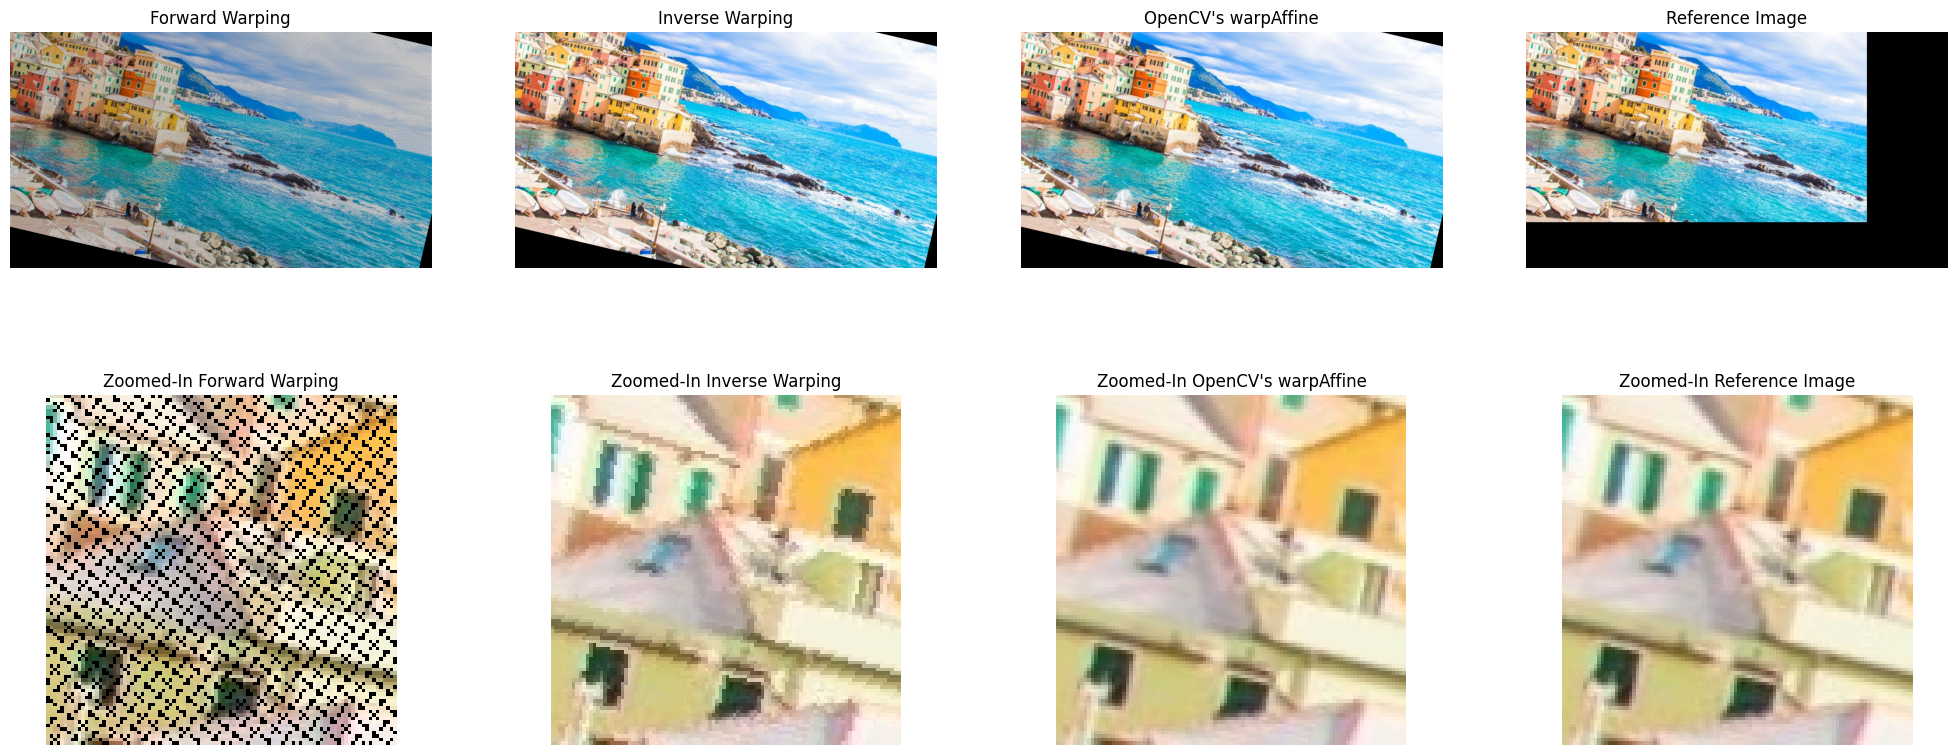

In [15]:
num_iterations = 30
num_points = 3
threshold = 10

# YOUR CODE HERE

## >>> SOLUTION

# Apply RANSAC to find the best transformation matrix
best_transformation_matrix = ransac_algorithm(keypoints_image_1, keypoints_image_2, matches, num_iterations, num_points, threshold)

# Visualize the different affine transformation methods
visualize_affine_transformations(image_1, image_2, best_transformation_matrix)

## <<< SOLUTION

<a id="question-6"></a>
#### <font color='#FF0000'>Question 6 (3 points)</font>

How many matches are required to solve an affine transformation formulated as follows:

$
\begin{bmatrix}
x'\\y'
\end{bmatrix} =
\begin{bmatrix}
m_1 & m_2\\
m_3 & m_4
\end{bmatrix}
\begin{bmatrix}
x\\y
\end{bmatrix} +
\begin{bmatrix}
t_1\\t_2
\end{bmatrix}
$

This equation can be rewritten as:

$
\begin{bmatrix}
x&y&0&0&1&0\\
0&0&x&y&0&1
\end{bmatrix}
\begin{bmatrix}
m_1\\
m_2\\
m_3\\
m_4\\
t_1\\
t_2
\end{bmatrix} =
\begin{bmatrix}
x'\\y'
\end{bmatrix}
$

Alternatively:

$
Ax = b, \;
A = \begin{bmatrix}
x&y&0&0&1&0\\
0&0&x&y&0&1
\end{bmatrix}, \;
x = \begin{bmatrix}
m_1\\
m_2\\
m_3\\
m_4\\
t_1\\
t_2
\end{bmatrix}, \;
b = \begin{bmatrix}
x'\\y'
\end{bmatrix}
$

##### <font color='yellow'>Answer:</font>

> Your answer here.

> ***FOR GRADING - Answers may include:***
> 
> - **Number of Unknowns:** The affine transformation has 6 unknowns: $m_1$, $m_2$, $m_3$, $m_4$, $t_1$, and $t_2$.
> 
> - **Number of Equations:** Each point match provides 2 equations.
> 
> - **Required Matches:** To solve for the 6 unknowns, 3 point matches are required, since 3 point matches will provide the necessary 6 equations.


<a id="question-7"></a>
#### <font color='#FF0000'>Question 7 (5 points)</font>

What happens if we have more point matches than the minimum required for solving an affine transformation? Will the code still work, and why?

##### <font color='yellow'>Answer:</font>

> Your answer here.

> ***FOR GRADING - Answers may include:***
>
> - **Code Adaptation:** If there are more point matches than the minimum required, the code needs to be adapted by vertically stacking the equations for matrices $A$ and $b$.
>
> - **Solution Approach:** With more than the minimum required matches, there likely won't be a closed-form solution. Instead, the least squares solution should be found using the pseudo-inverse of matrix $A$.
>
> - **Reasoning:** The pseudo-inverse allows us to minimize the error in over-determined systems, which occurs when more equations than unknowns are available.


<a id="question-8"></a>
#### <font color='#FF0000'>Question 8 (7 points)</font>

How many iterations are required in RANSAC to reliably find the correct transformation parameters? Provide a detailed explanation, and use mulitple figures to support your answer.

##### <font color='yellow'>Answer:</font>

> Your answer here.

> ***FOR GRADING - Answers may include:***
>
> - **Understanding of RANSAC Formula:** The student correctly uses the formula $1 - p = (1 - w^n)^k$ to calculate the required number of iterations ($k$) in RANSAC. They explain the variables: $p$ (desired probability), $n$ (number of points sampled per iteration), and $w$ (probability of selecting an inlier).
>
> - **Calculation and Explanation:** 
>   - The student correctly calculates $k$ using the formula $k = \frac{\log(1 - p)}{\log(1-w^n)}$.
>   - They identify $n = 3$, with 6416 matches, 5423 inliers, and $w \approx 0.845$.
>   - They provide $k$ values for different probabilities:
>     - $p = 99.99\%$, $k \approx 10$
>     - $p = 50\%$, $k \approx 1$
>
> - **Interpretation of Results:**
>   - The student correctly interprets that with 8 iterations, there's a very high probability (99.99%) of finding a match.
>   - They note that with 3 iterations, the probability is 90%, and with fewer than 2 iterations, the probability drops below 50%.
>   - The answer references an experiment that supports the calculations, noting that from about 3 iterations, a good transformation is consistently found.
>
> - **Overall Understanding:** The student demonstrates a clear understanding of how the number of iterations impacts the success rate of RANSAC in finding correct transformation parameters.

Number of iterations: 1
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 3
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 5
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 7
Total number of matches:  6416
Inliers found:            5425
Outliers removed:         991
Number of iterations: 10
Total number of matches:  6416
Inliers found:            5424
Outliers removed:         992
Number of iterations: 15
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 60
Total number of matches:  6416
Inliers found:            5424
Outliers removed:         992
Number of iterations: 100
Total number of matches:  6416
Inliers found:            5425
Outliers removed:         991


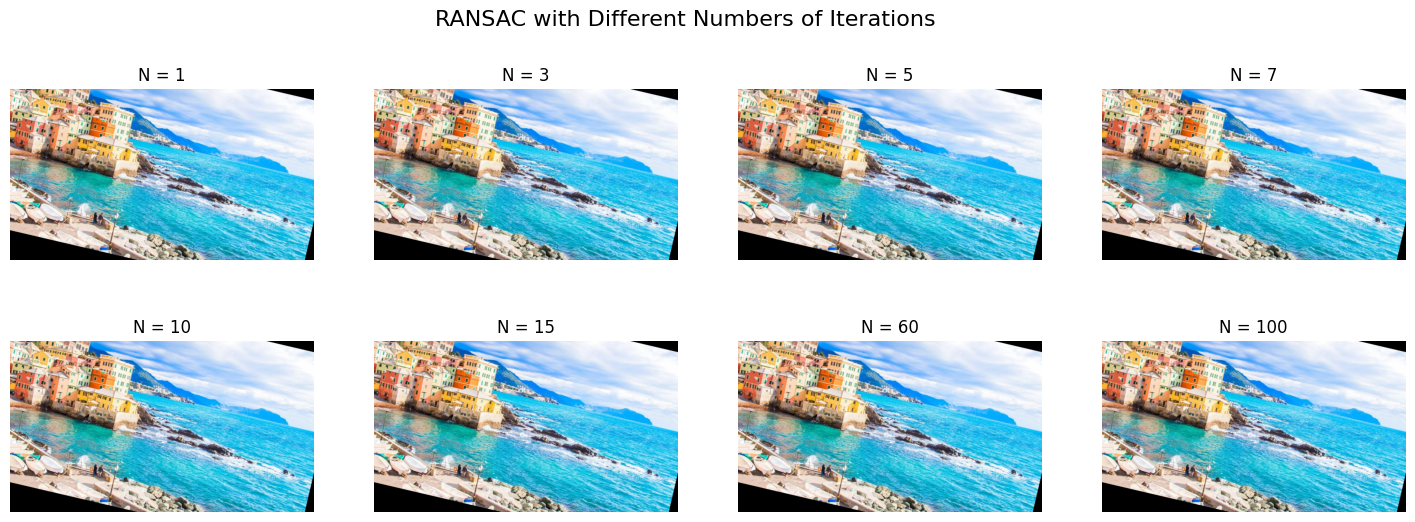

In [16]:
# YOUR CODE HERE

## >>> SOLUTION

# Sample arrays representing some values for iterations in RANSAC
NS1 = [1, 3, 5, 7]
NS2 = [10, 15, 60, 100]

# Combining the sample arrays into a numpy array for easy indexing
NS = np.array([NS1, NS2])

# Creating a subplot grid of 2x4 and defining the figure size
fig, axs = plt.subplots(2, 4, figsize=(18, 6))

# Looping through the 2D numpy array (2x4)
for i in range(2):
    for j in range(4):
        # Selecting the number of iterations (N) from the NS array
        N = NS[i, j]

        print(f"Number of iterations: {N}")
        # Getting the best transformation matrix by applying RANSAC on keypoints and matches
        # with the current number of iterations (N)
        best_matrix = ransac_algorithm(keypoints_image_1, keypoints_image_2, matches, N)

        # Applying an affine transformation to image_1 using the obtained best_matrix
        transformed_image = cv2.warpAffine(image_1, best_matrix, (image_1.shape[1], image_1.shape[0]))

        # Adding the transformed image to the subplot
        axs[i][j].imshow(transformed_image)
        
        # Setting title with number of iterations, total matches, and inliers
        axs[i][j].set_title(f"N = {N}")
        axs[i][j].axis('off')

# Add a title to the entire plot
fig.suptitle('RANSAC with Different Numbers of Iterations', fontsize=16)

# Displaying the entire grid of transformed images
plt.show()

## <<< SOLUTION

<a id="section-2"></a>
### **Section 2: Image Stitching**

In this section, we will explore the process of image stitching, a technique used to combine multiple images into a single, seamless panorama. This process involves aligning and blending overlapping images to create a larger, cohesive image. By determining the geometric transformation needed to align one image with another, we can map the images to a common coordinate system. Image stitching is widely used in various applications, including photography, computer vision, and virtual reality, where creating wide-angle or high-resolution images from multiple photos is essential.

<a id="question-9"></a>
#### <font color='#FF0000'>Question 9 (20 points)</font>

Create a function named **stitch_images_together()** that takes two images and the affine transformation matrix that maps `image_1` into the coordinate space of `image_2` (e.g. the matrix returned by your `ransac_algorithm()` from Question 3).

The function should:
- Estimate the size of the stitched output image, so that both images fit entirely (padded, not cropped).
- Transform `image_1` into the coordinate space of `image_2`, shifted so that no pixels fall at negative coordinates.
- Combine the transformed `image_1` with `image_2` to create the panorama.

The function should return the stitched image and `offset_image_2`, the (x, y) position of `image_2`'s top-left corner in the output image's coordinate system.

To stitch in the opposite direction (`image_2` onto `image_1`), call the same function with the images swapped and the corresponding transformation matrix (either recomputed with RANSAC or obtained by inverting the original one). You will do both directions in Questions 10 and 11.

**Note:** You can use `cv2.warpAffine` to apply the transformation to the images. However, you must implement the stitching yourself; built-in stitching functions from OpenCV (e.g. `cv2.Stitcher`) are **not** allowed.

In [17]:
def stitch_images_together(image_1, image_2, transformation_matrix):
    """
    Given two input images, stitch image_1 onto image_2.

    Args:
        image_1: The first image (in RGB).
        image_2: The second image (in RGB).
        transformation_matrix: Transformation matrix for image_1 to match image_2

    Returns:
        output_image: The stitched image combining the two input images.
        offset_image_2: Offset of image_2 in the new output image coordinate system.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Get image dimensions
    h1, w1 = image_1.shape[:2]
    h2, w2 = image_2.shape[:2]

    # Define the corner points of original images
    corners_image_1 = np.array([[0, 0], [0, h1], [w1, 0], [w1, h1]], dtype=np.float32)
    corners_image_2 = np.array([[0, 0], [0, h2], [w2, 0], [w2, h2]], dtype=np.float32)

    # Get transformed corners of the images
    transformed_corners_image_1 = cv2.transform(np.array([corners_image_1]), transformation_matrix).squeeze()
    all_corners = np.concatenate([transformed_corners_image_1, corners_image_2])

    # Determine size and offset of the output image
    xmin, ymin = np.min(all_corners, axis=0).astype(int)
    xmax, ymax = np.max(all_corners, axis=0).astype(int)
    output_width = xmax - xmin
    output_height = ymax - ymin
    offset_x, offset_y = -xmin, -ymin
    offset_image_2 = (offset_x, offset_y)

    # Create output image as an empty canvas
    output_image = np.zeros((output_height, output_width, 3), dtype=np.uint8)

    # Paste image_2 first into canvas in correct position
    output_image[offset_y:offset_y + h2, offset_x:offset_x + w2] = image_2

    # Define transformation of image_1 with respect to output_image coordinate system
    T = transformation_matrix.copy()
    T[:,2] += [offset_x, offset_y]

    # Warp the first image using the adjusted transformation matrix
    transformed_image_1 = cv2.warpAffine(image_1, T, (output_width, output_height))

    # Compute the mask for pasting image_1 onto output canvas image
    mask_1 = np.ones_like(image_1[...,0]) * 255
    transformed_mask_1 = cv2.warpAffine(mask_1, T, (output_width, output_height))
    transformed_mask_1 = transformed_mask_1 == 255  # bool

    # Paste image_1 into canvas on top of image_2 using the transformed mask
    output_image[transformed_mask_1] = transformed_image_1[transformed_mask_1]

    ## <<< SOLUTION

    return output_image, offset_image_2

<a id="question-10"></a>
#### <font color='#FF0000'>Question 10 (5 points)</font>

Write code to load the images `genoa_beach_cut_2.jpg` and `genoa_beach_cut_3.jpg`, stitch them together, and visualize the results. First, stitch `genoa_beach_cut_2.jpg` onto `genoa_beach_cut_3.jpg`, then perform the reverse operation by stitching `genoa_beach_cut_3.jpg` onto `genoa_beach_cut_2.jpg`. Visualize both original images and the resulting stitched images.

Finding matching features...
Number of keypoints in the first image:  5787
Number of keypoints in the second image: 5157
Number of matches: 2598
Total number of matches:  2598
Inliers found:            2000
Outliers removed:         598
Offset when stitching image_1 onto image_2: (311, 15)
Offset when stitching image_2 onto image_1: (0, 339)


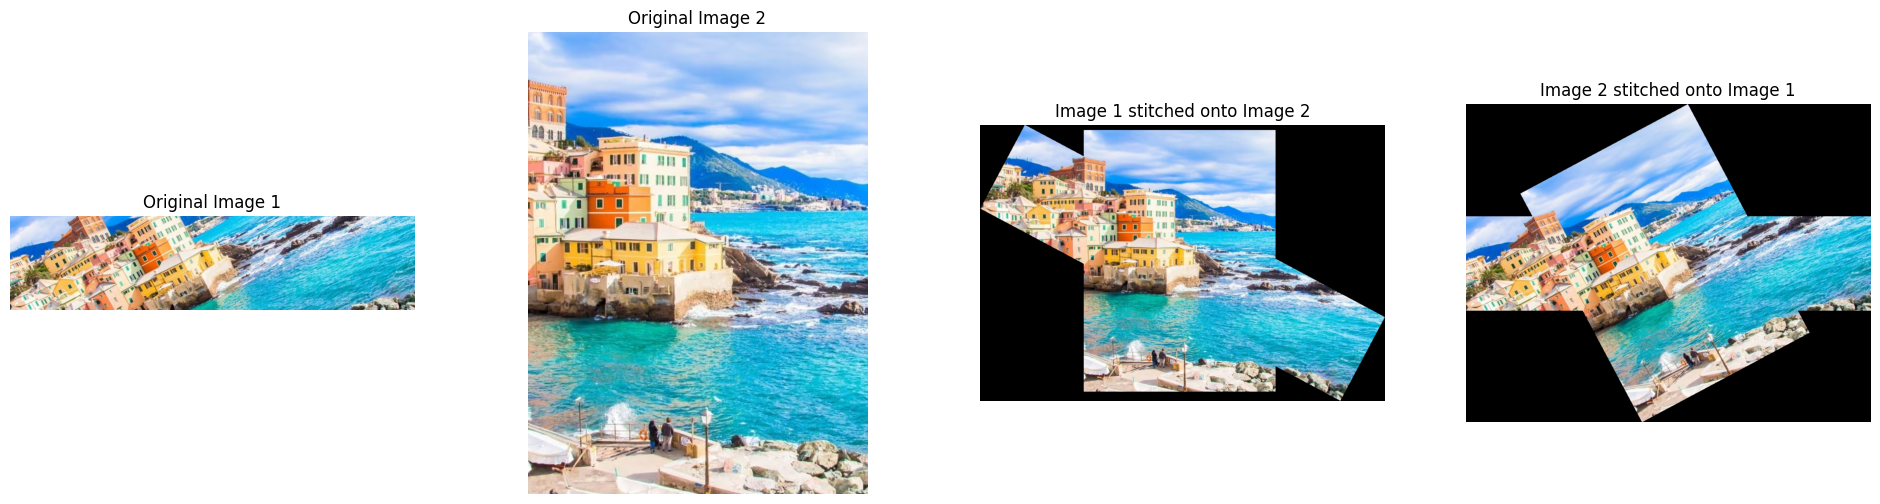

In [18]:
# YOUR CODE HERE

## >>> SOLUTION

# Load the images
image_1 = cv2.imread('images/genoa_beach_cut_2.jpg')
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread('images/genoa_beach_cut_3.jpg')
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

# Find matching keypoints between the two images
keypoints_1, keypoints_2, matches = get_matching_keypoints(image_1, image_2)

# Compute the best transformation matrix using RANSAC
transformation_matrix = ransac_algorithm(keypoints_1, keypoints_2, matches, num_iterations)

# Compute inverse transformation to avoid running RANSAC twice
inv_transformation_matrix = np.linalg.inv(np.vstack([transformation_matrix,[0,0,1]]))[:2,:]

# image_1 = (image_1 + [200,0,0]).clip(0,255).astype(np.uint8)  # AUX

# Stitch image_1 onto image_2
stitched_image_1_onto_2, offset_1_onto_2 = stitch_images_together(image_1, image_2, transformation_matrix)

print("Offset when stitching image_1 onto image_2:", offset_1_onto_2)

# Stitch image_2 onto image_1
stitched_image_2_onto_1, offset_2_onto_1 = stitch_images_together(image_2, image_1, inv_transformation_matrix)

print("Offset when stitching image_2 onto image_1:", offset_2_onto_1)

# Create a 1x4 subplot grid for displaying the results
plt.figure(figsize=(24, 6))

plt.subplot(1, 4, 1)
plt.imshow(image_1)
plt.axis('off')
plt.title('Original Image 1')

plt.subplot(1, 4, 2)
plt.imshow(image_2)
plt.axis('off')
plt.title('Original Image 2')

plt.subplot(1, 4, 3)
plt.imshow(stitched_image_1_onto_2)
plt.axis('off')
plt.title('Image 1 stitched onto Image 2')

plt.subplot(1, 4, 4)
plt.imshow(stitched_image_2_onto_1)
plt.axis('off')
plt.title('Image 2 stitched onto Image 1')

# plt.savefig('q10_test.png', bbox_inches='tight')  # AUX

plt.show()

## <<< SOLUTION

<a id="question-11"></a>
#### <font color='#FF0000'>Question 11 (5 points)</font>

Now, write code to load the images `sciencepark_1.jpg` and `sciencepark_2.jpg`, stitch them together, and visualize the results. First, stitch `sciencepark_1.jpg` onto `sciencepark_2.jpg`, then perform the reverse operation by stitching `sciencepark_2.jpg` onto `sciencepark_1.jpg`. Visualize both original images and the resulting stitched images.

Finding matching features...
Number of keypoints in the first image:  10659
Number of keypoints in the second image: 11343
Number of matches: 6218
Total number of matches:  6218
Inliers found:            5477
Outliers removed:         741
Offset when stitching image_1 onto image_2: (170, 117)
Offset when stitching image_2 onto image_1: (170, 117)


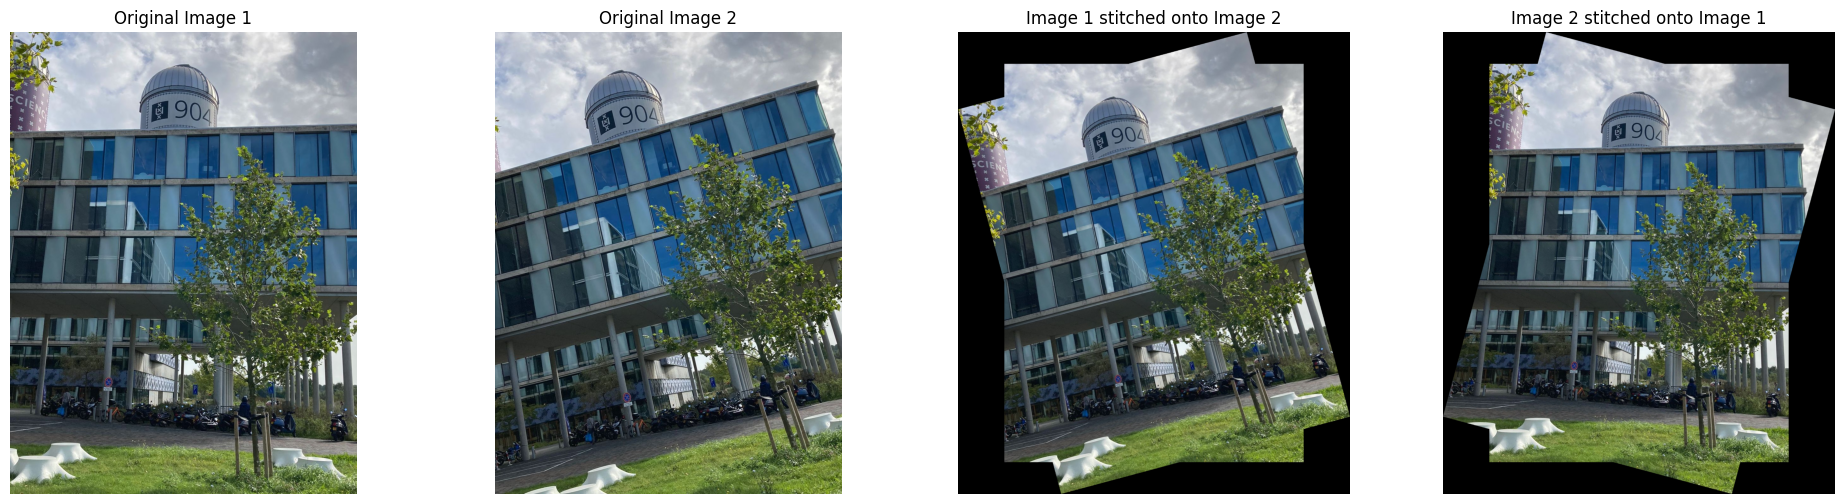

In [19]:
# YOUR CODE HERE

## >>> SOLUTION

# Load the images
image_1 = cv2.imread('images/sciencepark_1.jpg')
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread('images/sciencepark_2.jpg')
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

# Find matching keypoints between the two images
keypoints_1, keypoints_2, matches = get_matching_keypoints(image_1, image_2)

# Compute the best transformation matrix using RANSAC
transformation_matrix = ransac_algorithm(keypoints_1, keypoints_2, matches, num_iterations)

# Compute inverse transformation to avoid running RANSAC twice
inv_transformation_matrix = np.linalg.inv(np.vstack([transformation_matrix,[0,0,1]]))[:2,:]

# Stitch image_1 onto image_2
stitched_image_1_onto_2, offset_1_onto_2 = stitch_images_together(image_1, image_2, transformation_matrix)

print("Offset when stitching image_1 onto image_2:", offset_1_onto_2)

# Stitch image_2 onto image_1
stitched_image_2_onto_1, offset_2_onto_1 = stitch_images_together(image_2, image_1, inv_transformation_matrix)

print("Offset when stitching image_2 onto image_1:", offset_2_onto_1)

# Create a 1x4 subplot grid for displaying the results
plt.figure(figsize=(24, 6))

plt.subplot(1, 4, 1)
plt.imshow(image_1)
plt.axis('off')
plt.title('Original Image 1')

plt.subplot(1, 4, 2)
plt.imshow(image_2)
plt.axis('off')
plt.title('Original Image 2')

plt.subplot(1, 4, 3)
plt.imshow(stitched_image_1_onto_2)
plt.axis('off')
plt.title('Image 1 stitched onto Image 2')

plt.subplot(1, 4, 4)
plt.imshow(stitched_image_2_onto_1)
plt.axis('off')
plt.title('Image 2 stitched onto Image 1')

plt.show()

## <<< SOLUTION

<a id="section-3"></a>
### **Section 3: Automatic Panorama Stitching**

In this section, you will create a panorama by stitching together multiple images. The goal is to combine a series of images into a single, wide-angle view that captures the entire scene seamlessly. This process involves detecting features in each image, matching these features between consecutive images, and computing the geometric transformations needed to align and blend them into a cohesive panorama. By mapping the images to a common coordinate system using these transformations, you can effectively stitch them together into one continuous view.

<a id="question-12"></a>
#### <font color='#FF0000'>Question 12 (15 points)</font>

Create a function named **`automatic_panorama_stitching(images, use_mask=True)`** that stitches a series of images together to create a panorama. The function should accept a list of input images and manually implement the stitching process using feature detection and matching techniques. This includes performing feature matching between images, estimating the homography between matched features, and warping images to align them into a panorama.

The function should handle cases where stitching fails, providing appropriate error messages if necessary. After stitching, and based on the **`use_mask`** parameter, the function should crop the stitched image using the bounding rectangle to remove unnecessary areas, such as black borders.

Apply your function on the image paths provided below and visualize the results for each set of images. Make sure to **also** visualize the difference between **`use_mask`** set to **True** and **False**.

```python
image_paths = [
    'panorama_images/panorama_cut_1.jpg',
    'panorama_images/panorama_cut_2.jpg',
    'panorama_images/panorama_cut_3.jpg',
    'panorama_images/panorama_cut_4.jpg',
]

image_paths = [
    'panorama_images/panorama_2_cut_1.jpg',
    'panorama_images/panorama_2_cut_2.jpg',
    'panorama_images/panorama_2_cut_3.jpg',
    'panorama_images/panorama_2_cut_4.jpg',
    'panorama_images/panorama_2_cut_5.jpg',
    'panorama_images/panorama_2_cut_6.jpg',
    'panorama_images/panorama_2_cut_7.jpg',
    'panorama_images/panorama_2_cut_8.jpg',
]
```

**Note:** You are allowed to use any of the functions you have implemented in the previous sections, but you are also allowed to use any other functions from OpenCV (apart from cv2.Stitcher_create() which would make the question trivial).

In [20]:
def automatic_panorama_stitching(images, use_mask=True):
    """
    Automatically stitch a series of images together to create a panorama.

    Args:
        images: A list of input images to stitch together.
        use_mask: A boolean indicating whether to use a mask for the final stitched image. (default is True)

    Returns:
        stitched: The final stitched image.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Create a stitcher object
    stitcher = cv2.Stitcher_create()
    (status, stitched) = stitcher.stitch(images)

    if status != cv2.Stitcher_OK:
        print(f"Image stitching failed ({status})")
        return None

    # Add a 10 pixel border around the image
    stitched = cv2.copyMakeBorder(
        stitched, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )

    if use_mask:
        # Convert to grayscale and threshold
        gray = cv2.cvtColor(stitched, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)
    
        # Find contours in the thresholded image
        contours, _ = cv2.findContours(
            thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
    
        # Find the largest contour which will be the outline of the stitched image
        c = max(contours, key=cv2.contourArea)
    
        # Allocate mask for rectangular bounding box of stitched image region
        mask = np.zeros(thresh.shape, dtype="uint8")
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(mask, (x, y), (x + w, y + h), 255, -1)
    
        # Create two copies of the mask
        minRect = mask.copy()
        sub = mask.copy()
    
        # Keep looping until there are no non-zero pixels left in the subtracted image
        while cv2.countNonZero(sub) > 0:
            # Erode the minimum rectangular mask and subtract
            minRect = cv2.erode(minRect, None)
            sub = cv2.subtract(minRect, thresh)
    
        # Find contours in the minimum rectangular mask and extract bounding box
        contours, _ = cv2.findContours(
            minRect.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
    
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)

        # Use the bounding box coordinates to extract the final stitched image
        stitched = stitched[y : y + h, x : x + w]

    ## <<< SOLUTION

    return stitched

In [21]:
## ALT SOLUTION

def automatic_panorama_stitching(images, use_mask=True):

    def matmul(a,b):
        """ input: 2x3 matrices """
        a = np.vstack([a,[0,0,1]])  # 3x3
        b = np.vstack([b,[0,0,1]])  # 3x3
        c = a @ b
        return c[:2,:]

    pano = images[0]
    pano_mask = np.ones_like(pano) * 255
    cum_trans = np.array([[1,0,0],[0,1,0]])

    for i in range(len(images)-1):
        image_1 = images[i]
        image_2 = images[i+1]
        image_2_mask = np.ones_like(image_2) * 255

        keypoints_1, keypoints_2, matches = get_matching_keypoints(image_1, image_2)
        transformation_matrix = ransac_algorithm(keypoints_1, keypoints_2, matches, num_iterations=100)
        inv_transformation_matrix = np.linalg.inv(np.vstack([transformation_matrix,[0,0,1]]))[:2,:]

        cum_trans = matmul(cum_trans, inv_transformation_matrix)

        pano, offset = stitch_images_together(image_2, pano, cum_trans)
        pano_mask, offset = stitch_images_together(image_2_mask, pano_mask, cum_trans)

        cum_trans[:,2] += offset

    ## PCA align

    mask = (pano_mask == 255).all(axis=-1)

    xv, yv = np.mgrid[0:mask.shape[1],0:mask.shape[0]]
    xs = xv[mask.T]
    ys = yv[mask.T]
    coords = np.stack([xs,ys], axis=1)

    pca = PCA(n_components=2)
    new_coords = pca.fit_transform(coords)
    new_origin = new_coords[0]

    new_xs, new_ys = new_coords.T
    xmin, xmax = new_xs.min(), new_xs.max()
    ymin, ymax = new_ys.min(), new_ys.max()
    new_width = int(np.ceil(xmax - xmin))
    new_height = int(np.ceil(ymax - ymin))
    offset_x, offset_y = new_origin[0]-xmin, new_origin[1]-ymin

    # add frame
    frame_size = 10
    new_width += 2*frame_size
    new_height += 2*frame_size
    offset_x += frame_size
    offset_y += frame_size
    
    aff = np.hstack([pca.components_,np.array([[offset_x],[offset_y]])], dtype=float)
    
    pano_aligned = cv2.warpAffine(pano, aff, (new_width, new_height))

    stitched = pano_aligned

    if use_mask:
        ## crop
        
        mask_aligned = cv2.warpAffine(pano_mask, aff, (new_width, new_height))
        mask_aligned_bool = (mask_aligned == 255).all(axis=-1)
        plt.imshow(mask_aligned_bool)
        plt.show()
    
        # brute force incribed rect search
        
        img_center = np.array([new_width/2, new_height/2])
    
        def is_white(pmin,pmax):
            xmin, ymin = np.floor(pmin).astype(int)
            xmax, ymax = np.ceil(pmax).astype(int)
            return (mask_aligned_bool[ymin:ymax,xmin:xmax]).all()
    
        def plot_rect(pmin, pmax):
            from matplotlib.patches import Rectangle
            fig, ax = plt.subplots()
            plt.imshow(mask_aligned_bool)
            size = pmax-1 - pmin
            ax.add_patch(Rectangle(pmin, size[0], size[1], linewidth=1, edgecolor='r', facecolor='none'))
            plt.show()
    
        min_size = np.array([0, 0])  # is_white=True
        max_size = np.array([new_width, new_height])-2*frame_size  # is_white=False
        print('searching')
        n = 0
        while (max_size - min_size > .1).any():
            n += 1
            size_candidate = (max_size + min_size) / 2
            pmin = img_center - size_candidate / 2
            pmax = img_center + size_candidate / 2
            if is_white(pmin,pmax):
                min_size = size_candidate
            else:
                max_size = size_candidate
        print('n_iters:', n)
        
        best_pmin = np.ceil(img_center - min_size / 2).astype(int)
        best_pmax = np.floor(img_center + min_size / 2).astype(int)
        best_area = np.linalg.norm(best_pmax-best_pmin)**2
        print('best:', best_pmin, best_pmax, best_area)
    
        print('searching')
        n = 0
        while True:
            n += 1
            pmin_candidates = [(best_pmin + d).copy() for d in ([1,0], [-1,0], [0,1], [0,-1], [1,1], [-1,-1], [1,-1], [-1,1])]
            pmax_candidates = [(best_pmax + d).copy() for d in ([1,0], [-1,0], [0,1], [0,-1], [1,1], [-1,-1], [1,-1], [-1,1])]
            batch_best_pmin = best_pmin.copy()
            batch_best_pmax = best_pmax.copy()
            batch_best_area = best_area
            found_better = False
            for pmin in pmin_candidates:
                for pmax in pmax_candidates:
                    area = np.linalg.norm(pmax-pmin)**2
                    if is_white(pmin,pmax) and area > batch_best_area:
                        batch_best_pmin = pmin.copy()
                        batch_best_pmax = pmax.copy()
                        batch_best_area = area
                        found_better = True
            if not found_better:
                break
            best_pmin = batch_best_pmin.copy()
            best_pmax = batch_best_pmax.copy()
            best_area = batch_best_area
        print('n_iters:', n)
            
        print('best:', best_pmin, best_pmax, best_area)
        plot_rect(best_pmin,best_pmax)
    
        xmin, ymin = pmin
        xmax, ymax = pmax
        pano_aligned_cropped = pano_aligned[ymin:ymax,xmin:xmax]
    
        stitched = pano_aligned_cropped

    return stitched

Image 1 loaded successfully with shape (541, 407, 3)
Image 2 loaded successfully with shape (541, 407, 3)
Image 3 loaded successfully with shape (541, 407, 3)
Image 4 loaded successfully with shape (541, 407, 3)
Finding matching features...
Number of keypoints in the first image:  1346
Number of keypoints in the second image: 1451
Number of matches: 654
Total number of matches:  654
Inliers found:            464
Outliers removed:         190
Finding matching features...
Number of keypoints in the first image:  1451
Number of keypoints in the second image: 1504
Number of matches: 572
Total number of matches:  572
Inliers found:            303
Outliers removed:         269
Finding matching features...
Number of keypoints in the first image:  1504
Number of keypoints in the second image: 1938
Number of matches: 687
Total number of matches:  687
Inliers found:            422
Outliers removed:         265


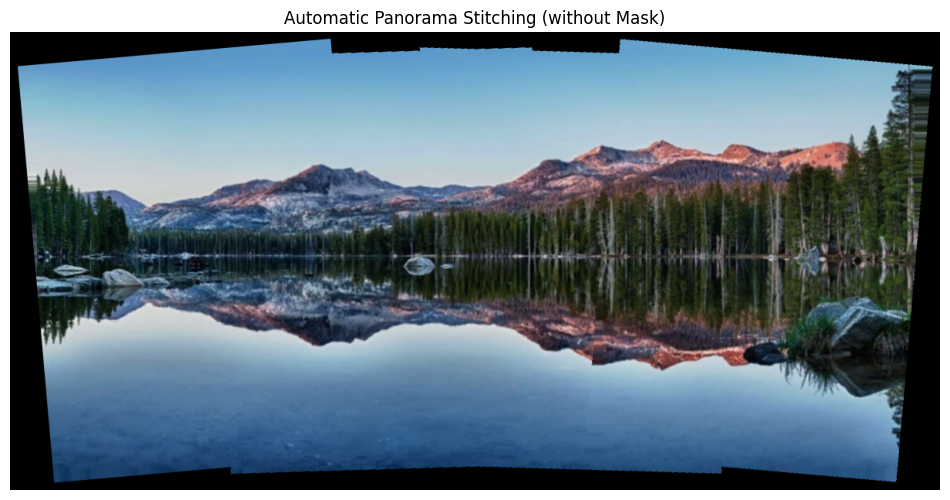

Successfully stitched panorama 2 without mask.
Finding matching features...
Number of keypoints in the first image:  1346
Number of keypoints in the second image: 1451
Number of matches: 654
Total number of matches:  654
Inliers found:            465
Outliers removed:         189
Finding matching features...
Number of keypoints in the first image:  1451
Number of keypoints in the second image: 1504
Number of matches: 572
Total number of matches:  572
Inliers found:            303
Outliers removed:         269
Finding matching features...
Number of keypoints in the first image:  1504
Number of keypoints in the second image: 1938
Number of matches: 687
Total number of matches:  687
Inliers found:            422
Outliers removed:         265


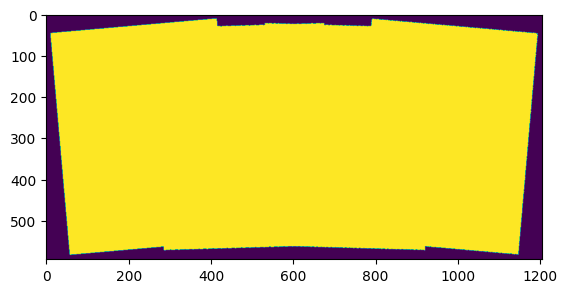

searching
n_iters: 14
best: [75 42] [1130  552] 1373125.0
searching
n_iters: 20
best: [56 43] [1149  563] 1465048.9999999998


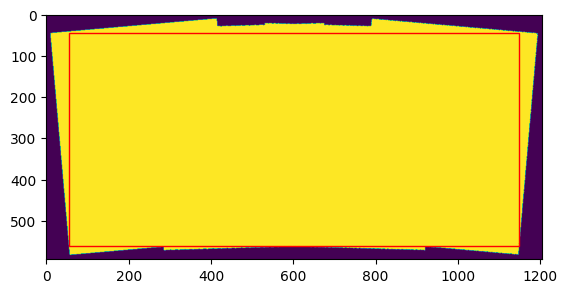

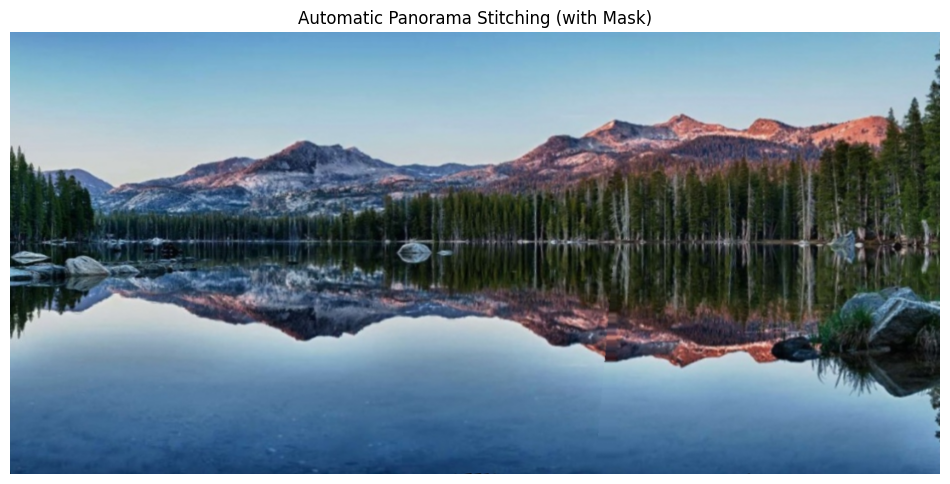

Successfully stitched panorama 2 with mask.


In [22]:
# YOUR CODE HERE

## >>> SOLUTION

# Image paths
image_paths = [
    'panorama_images/panorama_cut_1.jpg',
    'panorama_images/panorama_cut_2.jpg',
    'panorama_images/panorama_cut_3.jpg',
    'panorama_images/panorama_cut_4.jpg',
]

# Check if files exist
for path in image_paths:
    if not os.path.isfile(path):
        print(f"File not found: {path}")

# Load images
images = [cv2.imread(path) for path in image_paths]

# Verify that images are loaded
for idx, img in enumerate(images):
    if img is None:
        print(f"Image {idx+1} failed to load.")
    else:
        print(f"Image {idx+1} loaded successfully with shape {img.shape}")

# Perform automatic panorama stitching
stitched_image = automatic_panorama_stitching(images, use_mask=False)

if stitched_image is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (without Mask)')
    plt.show()
    print("Successfully stitched panorama 2 without mask.")

# Perform automatic panorama stitching
stitched_image_with_mask = automatic_panorama_stitching(images, use_mask=True)

if stitched_image_with_mask is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image_with_mask, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (with Mask)')
    plt.show()
    print("Successfully stitched panorama 2 with mask.")

## <<< SOLUTION

Image 1 loaded successfully with shape (2832, 2186, 3)
Image 2 loaded successfully with shape (2832, 2186, 3)
Image 3 loaded successfully with shape (2832, 2186, 3)
Image 4 loaded successfully with shape (2832, 2186, 3)
Image 5 loaded successfully with shape (2832, 2186, 3)
Image 6 loaded successfully with shape (2832, 2186, 3)
Image 7 loaded successfully with shape (2832, 2186, 3)
Image 8 loaded successfully with shape (2832, 2186, 3)
Finding matching features...
Number of keypoints in the first image:  5833
Number of keypoints in the second image: 7838
Number of matches: 4423
Total number of matches:  4423
Inliers found:            4152
Outliers removed:         271
Finding matching features...
Number of keypoints in the first image:  7838
Number of keypoints in the second image: 8859
Number of matches: 5378
Total number of matches:  5378
Inliers found:            4984
Outliers removed:         394
Finding matching features...
Number of keypoints in the first image:  8859
Number of k

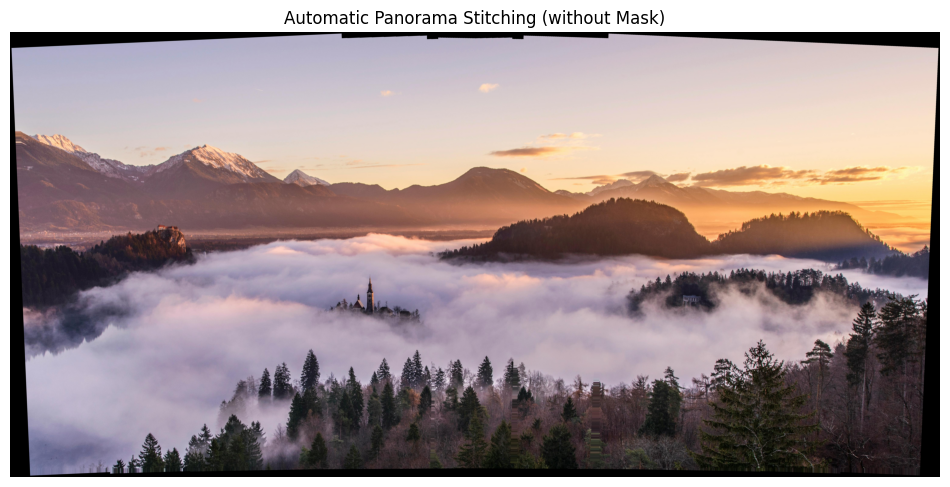

Successfully stitched panorama 2 without mask.
Finding matching features...
Number of keypoints in the first image:  5833
Number of keypoints in the second image: 7838
Number of matches: 4423
Total number of matches:  4423
Inliers found:            4152
Outliers removed:         271
Finding matching features...
Number of keypoints in the first image:  7838
Number of keypoints in the second image: 8859
Number of matches: 5378
Total number of matches:  5378
Inliers found:            4984
Outliers removed:         394
Finding matching features...
Number of keypoints in the first image:  8859
Number of keypoints in the second image: 8492
Number of matches: 5690
Total number of matches:  5690
Inliers found:            5319
Outliers removed:         371
Finding matching features...
Number of keypoints in the first image:  8492
Number of keypoints in the second image: 8643
Number of matches: 5475
Total number of matches:  5475
Inliers found:            5063
Outliers removed:         412
Findi

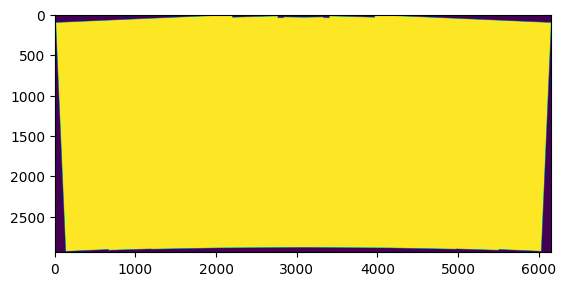

searching
n_iters: 16
best: [195  99] [5958 2845] 40752685.0
searching
n_iters: 64
best: [132 101] [6021 2885] 42430977.00000001


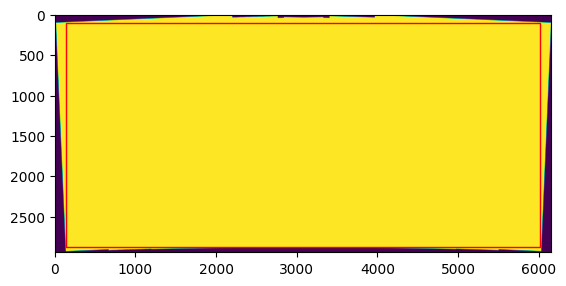

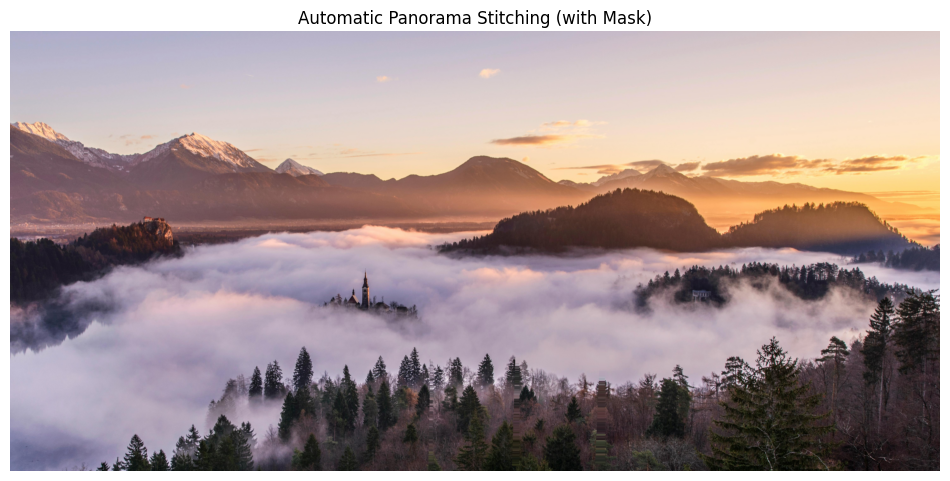

Successfully stitched panorama 2 with mask.


In [23]:
# YOUR CODE HERE

## >>> SOLUTION

# Image paths for panorama 2
image_paths_2 = [
    'panorama_images/panorama_2_cut_1.jpg',
    'panorama_images/panorama_2_cut_2.jpg',
    'panorama_images/panorama_2_cut_3.jpg',
    'panorama_images/panorama_2_cut_4.jpg',
    'panorama_images/panorama_2_cut_5.jpg',
    'panorama_images/panorama_2_cut_6.jpg',
    'panorama_images/panorama_2_cut_7.jpg',
    'panorama_images/panorama_2_cut_8.jpg',
]

# Check if files exist
for path in image_paths_2:
    if not os.path.isfile(path):
        print(f"File not found: {path}")

# Load images
images_2 = [cv2.imread(path) for path in image_paths_2]

# Verify that images are loaded
for idx, img in enumerate(images_2):
    if img is None:
        print(f"Image {idx+1} failed to load.")
    else:
        print(f"Image {idx+1} loaded successfully with shape {img.shape}")

# Perform automatic panorama stitching
stitched_image_2 = automatic_panorama_stitching(images_2, use_mask=False)

if stitched_image_2 is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image_2, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (without Mask)')
    plt.show()
    print("Successfully stitched panorama 2 without mask.")

# Perform automatic panorama stitching
stitched_image_2_with_mask = automatic_panorama_stitching(images_2, use_mask=True)

if stitched_image_2_with_mask is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image_2_with_mask, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (with Mask)')
    plt.show()
    print("Successfully stitched panorama 2 with mask.")

## <<< SOLUTION

<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |

### - End of Notebook -